In [3]:
import anndata as ad


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/kpax/Documents/aep/study/MSC/lab/ppmi-wip/ppmi-env/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/kpax/Documents/aep/study/MSC/lab/ppmi-wip/ppmi-env/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/kpax/Documents/aep/study/MSC/lab/ppmi-wip/ppmi-env/lib/python3.

In [4]:
ppmi_ad = ad.read_h5ad("/Users/kpax/Documents/aep/study/MSC/lab/PPMI_Project_133_RNASeq/ppmi_adata.h5ad")

/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_9912/3094622893.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gender_counts = ppmi_ad.obs.groupby('Gender')['Patient'].nunique()
/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_9912/3094622893.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gender_cohort_counts = ppmi_ad.obs.groupby(['Gender', 'Diagnosis'])['Patient'].nunique().unstack(fill_value=0)
/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_9912/3094622893.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future ve

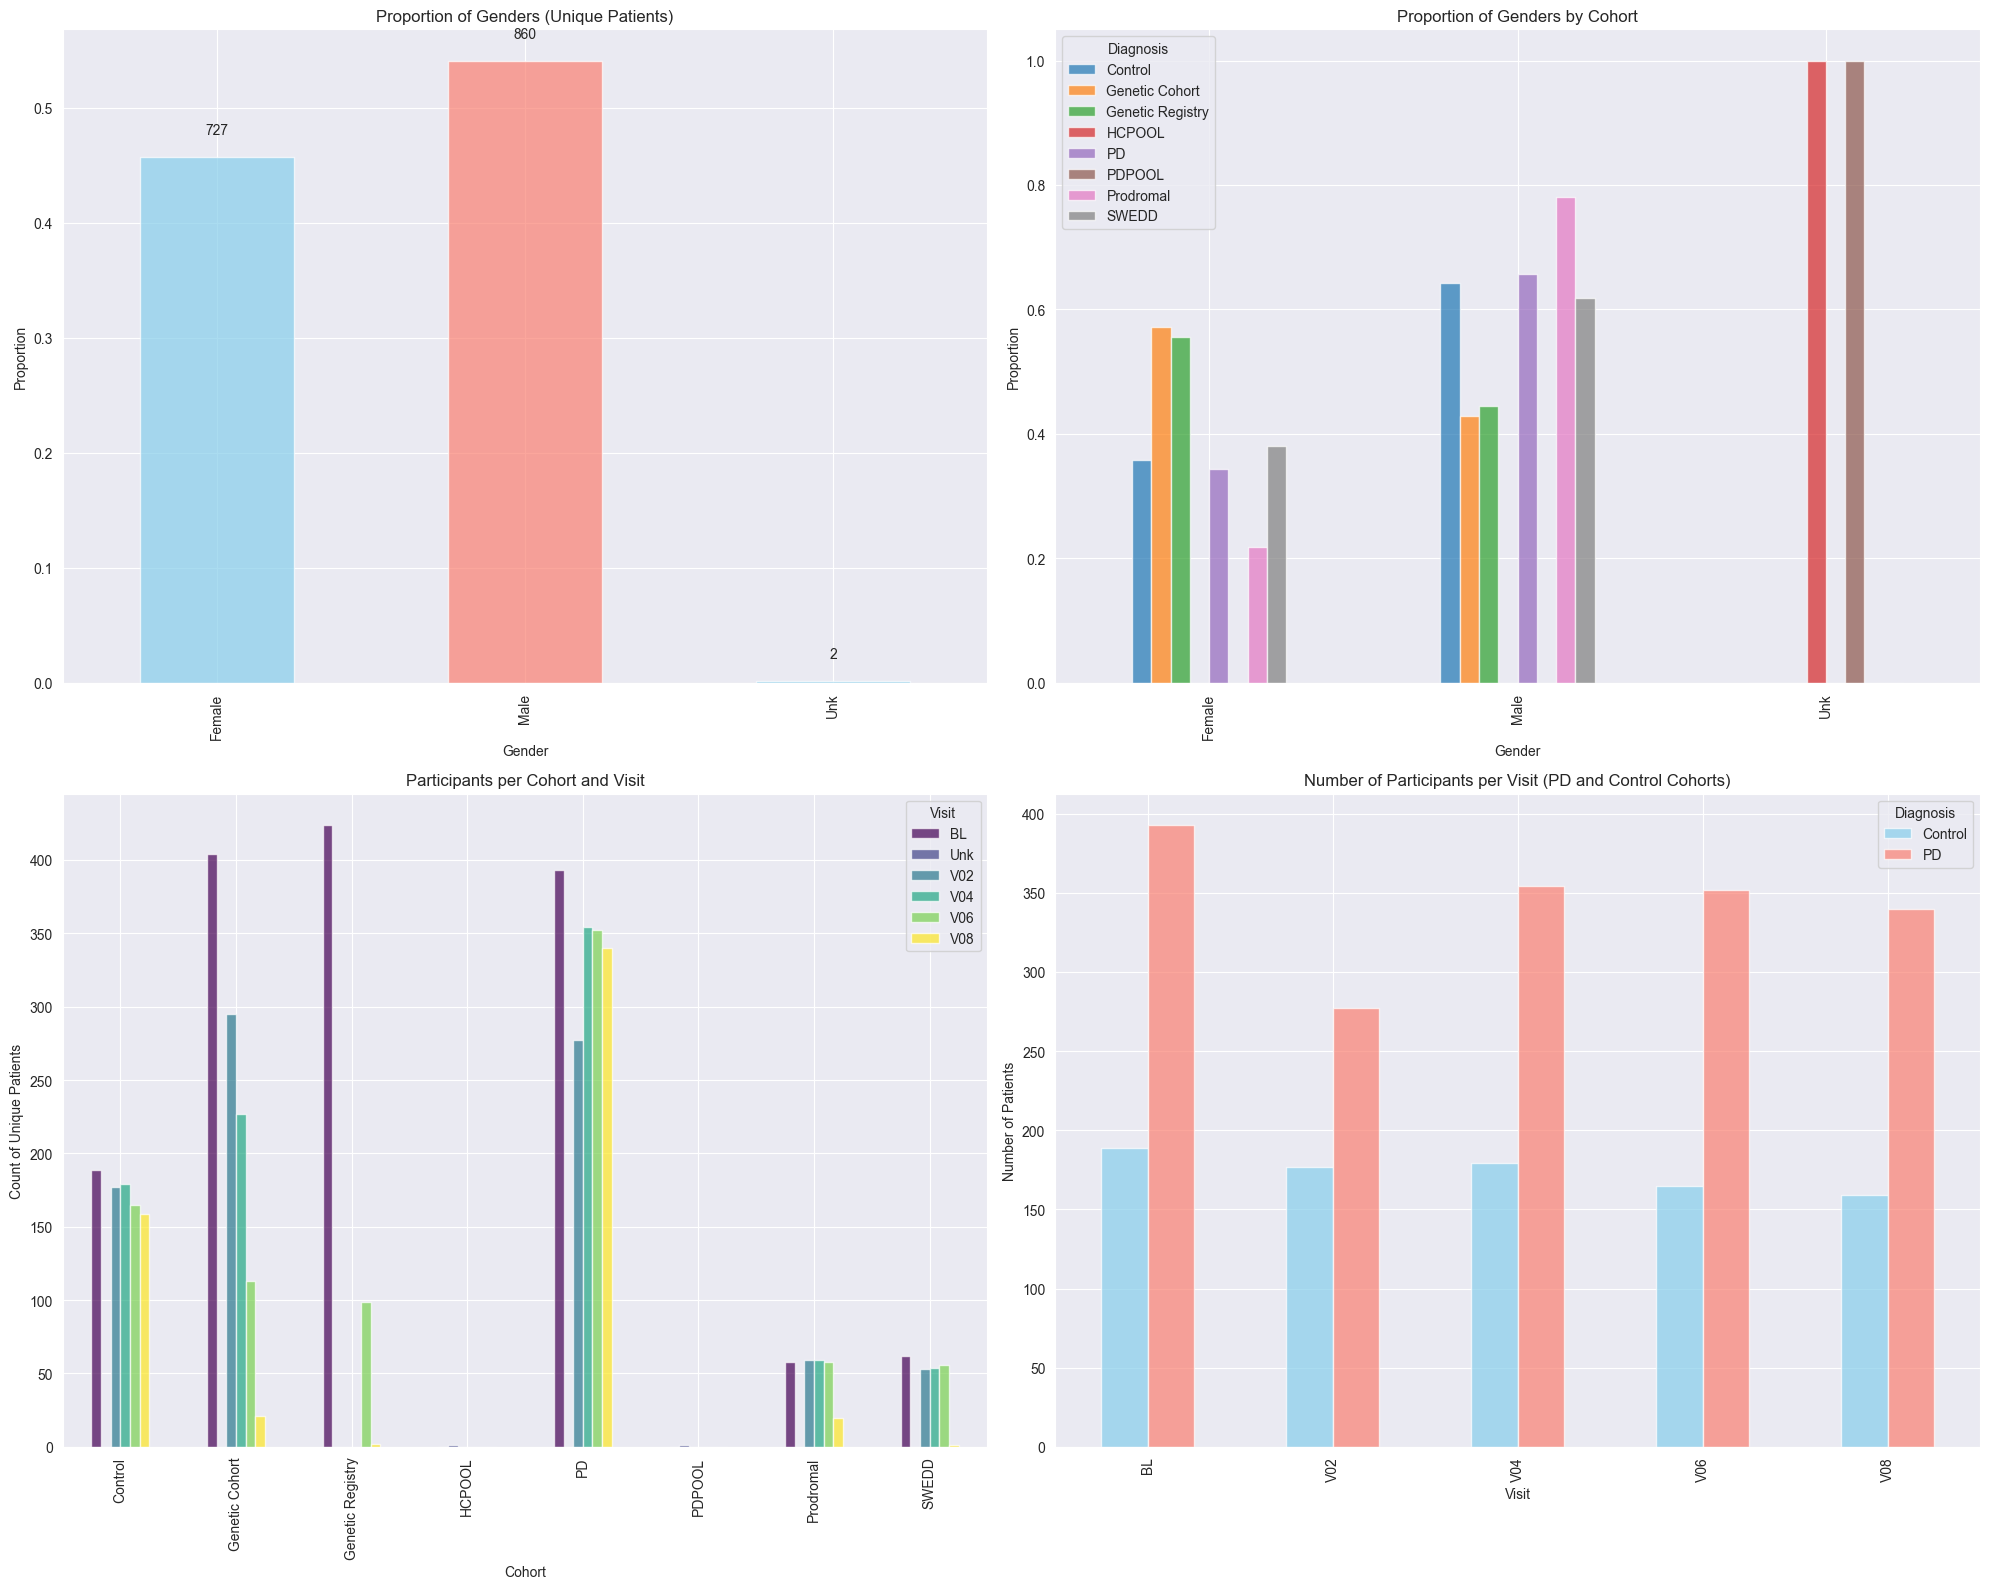

In [56]:
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(20, 16))
gs = GridSpec(2, 2, figure=fig)

# First plot: Proportion of Genders (Unique Patients)
ax1 = fig.add_subplot(gs[0, 0])
gender_counts = ppmi_ad.obs.groupby('Gender')['Patient'].nunique()
total_patients = ppmi_ad.obs['Patient'].nunique()
gender_proportions = gender_counts / total_patients
gender_proportions.plot(kind='bar', color=['skyblue', 'salmon'], alpha=0.7, ax=ax1)

# Annotate the plot with absolute numbers
for i, count in enumerate(gender_counts):
    ax1.text(i, gender_proportions.iloc[i] + 0.02, f'{count}', ha='center', fontsize=10)
ax1.set_title('Proportion of Genders (Unique Patients)')
ax1.set_ylabel('Proportion')
ax1.set_xlabel('Gender')

# Second plot: Proportion of Genders by Cohort
ax2 = fig.add_subplot(gs[0, 1])
color_map = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
gender_cohort_counts = ppmi_ad.obs.groupby(['Gender', 'Diagnosis'])['Patient'].nunique().unstack(fill_value=0)
gender_cohort_counts = gender_cohort_counts.div(gender_cohort_counts.sum(axis=0), axis=1)

gender_cohort_counts.plot(kind='bar', stacked=False, color=color_map, alpha=0.7, ax=ax2)
ax2.set_title('Proportion of Genders by Cohort')
ax2.set_ylabel('Proportion')
ax2.set_xlabel('Gender')

ax3 = fig.add_subplot(gs[1, 0])

samples_per_cohort = ppmi_ad.obs.groupby(['Diagnosis', 'Visit'])['Patient'].nunique().unstack(fill_value=0)
samples_per_cohort.plot(kind='bar', stacked=False, alpha=0.7, colormap='viridis', ax=ax3)
ax3.set_title('Participants per Cohort and Visit')
ax3.set_ylabel('Count of Unique Patients')
ax3.set_xlabel('Cohort')
# ax1.set_xticks(rotation=45, horizontalalignment='right')
# ax1.set_legend(title='Visit')

ax4 = fig.add_subplot(gs[1, 1])

samples_per_visit = (
    ppmi_ad.obs[ppmi_ad.obs['Diagnosis'].isin(['PD', 'Control'])]
    .groupby(['Visit', 'Diagnosis'])['Patient']
    .nunique()
    .unstack(fill_value=0)
)

# Filter out the 'Unk' Visit
samples_per_visit = samples_per_visit[samples_per_visit.index != 'Unk']

samples_per_visit[['Control', 'PD']].plot(kind='bar', stacked=False, color=['skyblue', 'salmon'], alpha=0.7, ax=ax4)

ax4.set_title('Number of Participants per Visit (PD and Control Cohorts)')
ax4.set_ylabel('Number of Patients')
ax4.set_xlabel('Visit')

plt.tight_layout()
plt.show()

In [44]:
ppmi_ad = ad.read_h5ad("/Users/kpax/Documents/aep/study/MSC/lab/PPMI_Project_133_RNASeq/ppmi_adata.h5ad")

/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_9912/2678040205.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samples_per_visit_gender.groupby(['Visit', 'Diagnosis', 'Gender'])['Patient']
/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_9912/2678040205.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Age_Group', 'Diagnosis'])['Patient']
/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_9912/2678040205.py:80: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curr

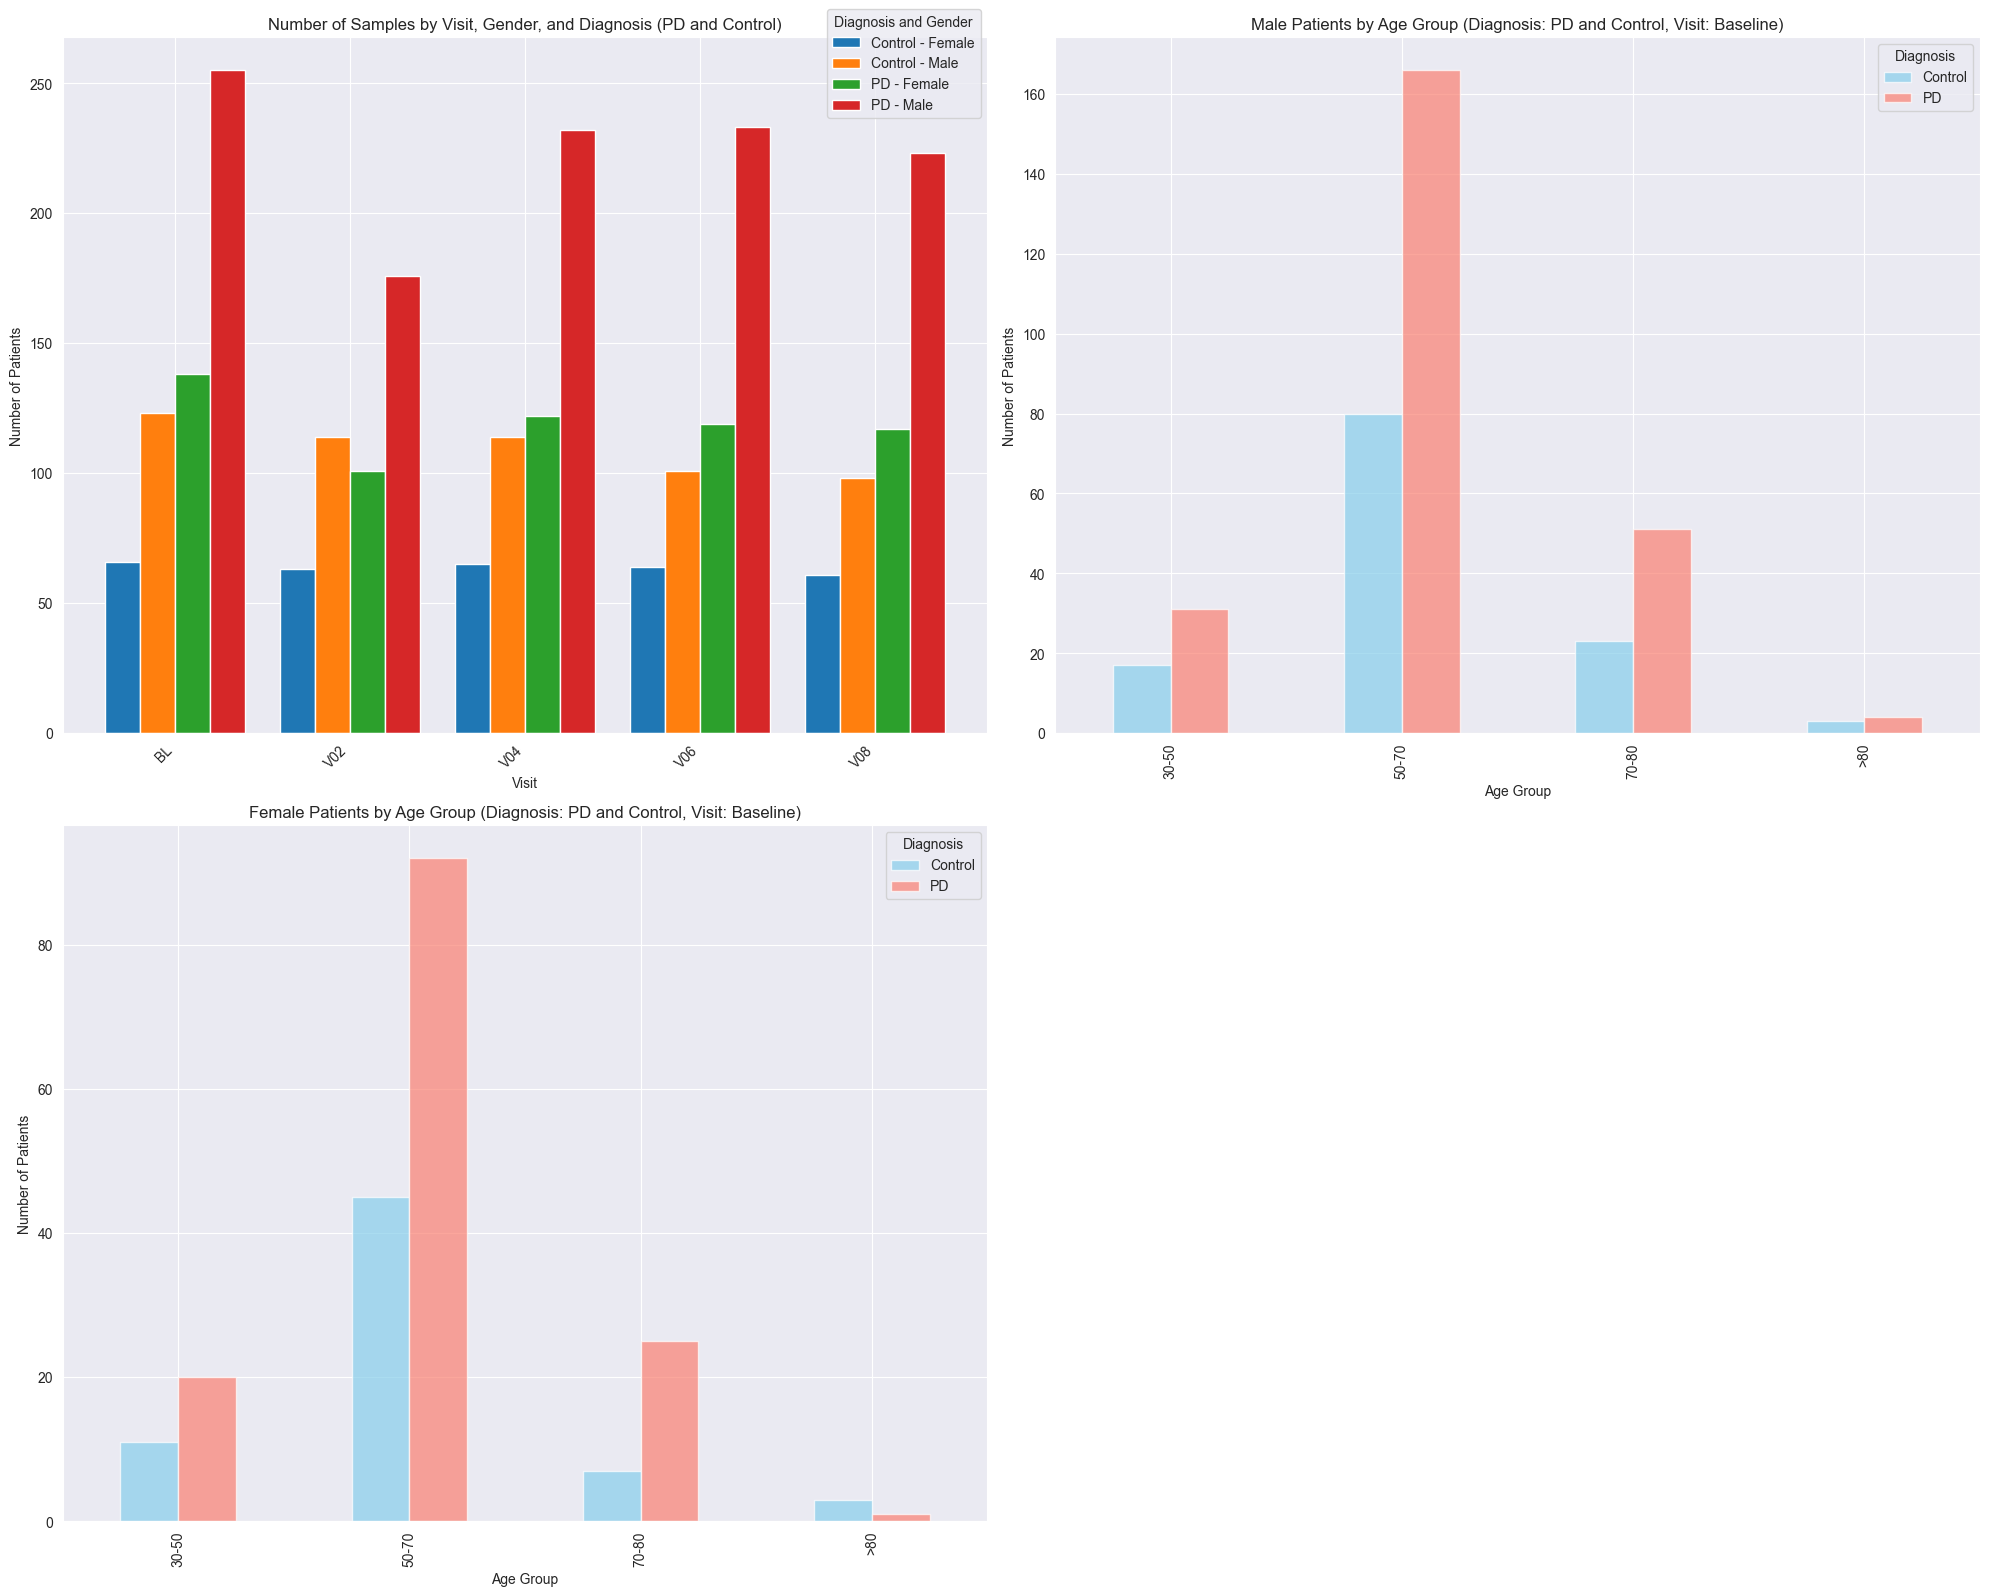

In [91]:
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(20, 16))
gs = GridSpec(2, 2, figure=fig)

# First plot: Proportion of Genders (Unique Patients)
ax1 = fig.add_subplot(gs[0, 0])

samples_per_visit_gender = (
    ppmi_ad.obs[ppmi_ad.obs['Diagnosis'].isin(['PD', 'Control'])]
)

samples_per_visit_gender = (
    samples_per_visit_gender.groupby(['Visit', 'Diagnosis', 'Gender'])['Patient']
    .nunique()
    .unstack(['Diagnosis', 'Gender'], fill_value=0)
)

# Remove columns that have all zeros
samples_per_visit_gender = samples_per_visit_gender.loc[:, (samples_per_visit_gender != 0).any(axis=0)]

# Filter out the 'Unk' Visit
samples_per_visit_gender = samples_per_visit_gender[samples_per_visit_gender.index != 'Unk']

# Generate the barplot with distinct bars for PD and Control
bar_width = 0.2  # Width of each bar
x = range(len(samples_per_visit_gender.index))  # X positions for the bars

# Plot each combination of Diagnosis and Gender using distinct bars
for i, (diagnosis, gender) in enumerate(samples_per_visit_gender.columns):
    ax1.bar(
        [pos + i * bar_width for pos in x],  # Adjust position for each bar
        samples_per_visit_gender[(diagnosis, gender)],
        width=bar_width,
        label=f"{diagnosis} - {gender}"
    )
ax1.set_title('Number of Samples by Visit, Gender, and Diagnosis (PD and Control)')
ax1.set_ylabel('Number of Patients')
ax1.set_xlabel('Visit')
ax1.set_xticks([pos + bar_width * (len(samples_per_visit_gender.columns) / 2 - 0.5) for pos in x])  # Center xticks
ax1.set_xticklabels(samples_per_visit_gender.index, rotation=45, horizontalalignment='right')
ax1.legend(title='Diagnosis and Gender', loc='upper right', bbox_to_anchor=(1.0, 1.05))

# Second plot: Proportion of Genders by Cohort
ax2 = fig.add_subplot(gs[0, 1])

mask = ((ppmi_ad.obs['Gender'] == 'Male') &
        (ppmi_ad.obs['Diagnosis'].isin(['PD', 'Control'])) &
        (ppmi_ad.obs['Age_Group'] != 'Unknown') &
        (ppmi_ad.obs['Visit'] == 'BL'))

ppmi_ad_masked_m = ppmi_ad[mask]

baseline_age_counts = (
    ppmi_ad_masked_m.obs
    .groupby(['Age_Group', 'Diagnosis'])['Patient']
    .nunique()
    .unstack(fill_value=0)
)
baseline_age_counts.plot(kind='bar', stacked=False, color=['skyblue', 'salmon'], alpha=0.7, ax=ax2)

ax2.set_title('Male Patients by Age Group (Diagnosis: PD and Control, Visit: Baseline)')
ax2.set_ylabel('Number of Patients')
ax2.set_xlabel('Age Group')
# ax2.set_xticks(rotation=45, horizontalalignment='right')
ax2.legend(title='Diagnosis')

ax3 = fig.add_subplot(gs[1, 0])

mask = ((ppmi_ad.obs['Gender'] == 'Female') &
        (ppmi_ad.obs['Diagnosis'].isin(['PD', 'Control'])) &
        (ppmi_ad.obs['Age_Group'] != 'Unknown') &
        (ppmi_ad.obs['Visit'] == 'BL'))

ppmi_ad_masked_f = ppmi_ad[mask]

baseline_age_counts = (
    ppmi_ad_masked_f.obs
    .groupby(['Age_Group', 'Diagnosis'])['Patient']
    .nunique()
    .unstack(fill_value=0)
)

baseline_age_counts.plot(kind='bar', stacked=False, color=['skyblue', 'salmon'], alpha=0.7, ax=ax3)

ax3.set_title('Female Patients by Age Group (Diagnosis: PD and Control, Visit: Baseline)')
ax3.set_ylabel('Number of Patients')
ax3.set_xlabel('Age Group')
# ax3.set_xticks(rotation=45, horizontalalignment='right')
ax3.legend(title="Diagnosis")

# ax4 = fig.add_subplot(gs[1, 1])
#
#
# ax4.set_title('Number of Participants per Visit (PD and Control Cohorts)')
# ax4.set_ylabel('Number of Patients')
# ax4.set_xlabel('Visit')

plt.tight_layout()
plt.show()

/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_9912/7214144.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samples_per_cohort = ppmi_ad.obs.groupby(['Diagnosis', 'Visit'])['Patient'].nunique().unstack(fill_value=0)
/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_9912/7214144.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Visit', 'Diagnosis'])['Patient']


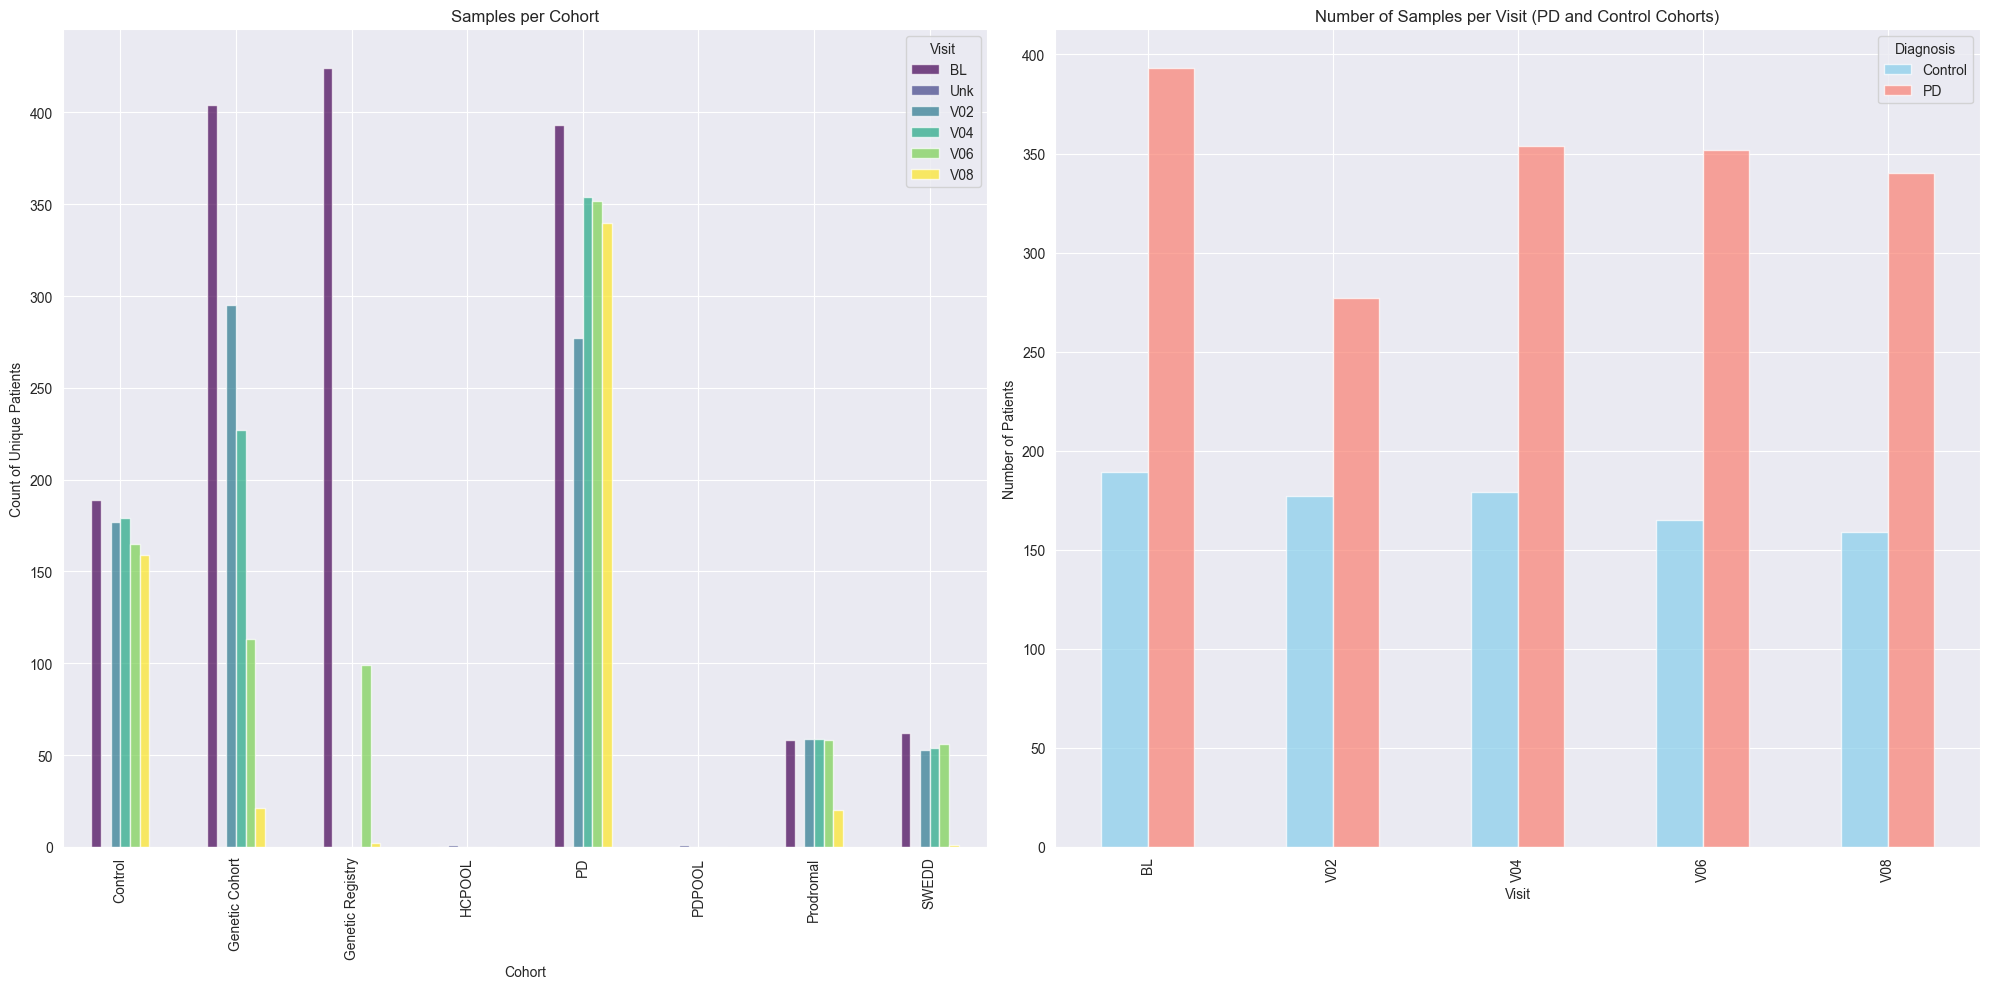

In [51]:
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(20, 10))
gs = GridSpec(1, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])

samples_per_cohort = ppmi_ad.obs.groupby(['Diagnosis', 'Visit'])['Patient'].nunique().unstack(fill_value=0)
samples_per_cohort.plot(kind='bar', stacked=False, alpha=0.7, colormap='viridis', ax=ax1)
ax1.set_title('Samples per Cohort')
ax1.set_ylabel('Count of Unique Patients')
ax1.set_xlabel('Cohort')
# ax1.set_xticks(rotation=45, horizontalalignment='right')
# ax1.set_legend(title='Visit')

ax2 = fig.add_subplot(gs[0, 1])

samples_per_visit = (
    ppmi_ad.obs[ppmi_ad.obs['Diagnosis'].isin(['PD', 'Control'])]
    .groupby(['Visit', 'Diagnosis'])['Patient']
    .nunique()
    .unstack(fill_value=0)
)

# Filter out the 'Unk' Visit
samples_per_visit = samples_per_visit[samples_per_visit.index != 'Unk']

samples_per_visit[['Control', 'PD']].plot(kind='bar', stacked=False, color=['skyblue', 'salmon'], alpha=0.7, ax=ax2)

ax2.set_title('Number of Samples per Visit (PD and Control Cohorts)')
ax2.set_ylabel('Number of Patients')
ax2.set_xlabel('Visit')
# ax2.set_xticks(rotation=45, horizontalalignment='right')
# plt.legend(title='Diagnosis')

plt.tight_layout()
plt.show()

/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_9358/3257530315.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samples_per_cohort = ppmi_ad.obs.groupby(['Diagnosis', 'Visit'])['Patient'].nunique().unstack(fill_value=0)


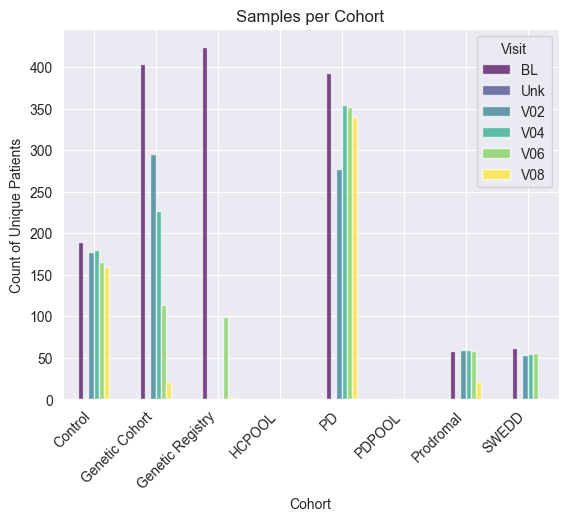

In [28]:
# Count unique patients per Diagnosis and Visit
samples_per_cohort = ppmi_ad.obs.groupby(['Diagnosis', 'Visit'])['Patient'].nunique().unstack(fill_value=0)
samples_per_cohort.plot(kind='bar', stacked=False, alpha=0.7, colormap='viridis')
plt.title('Samples per Cohort')
plt.ylabel('Count of Unique Patients')
plt.xlabel('Cohort')
plt.xticks(rotation=45, horizontalalignment='right')
plt.legend(title='Visit')
plt.show()

/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_39883/3209609582.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_gender_counts = ppmi_ad.obs.groupby(['Age_Group', 'Gender'])['Patient'].nunique().unstack(fill_value=0)


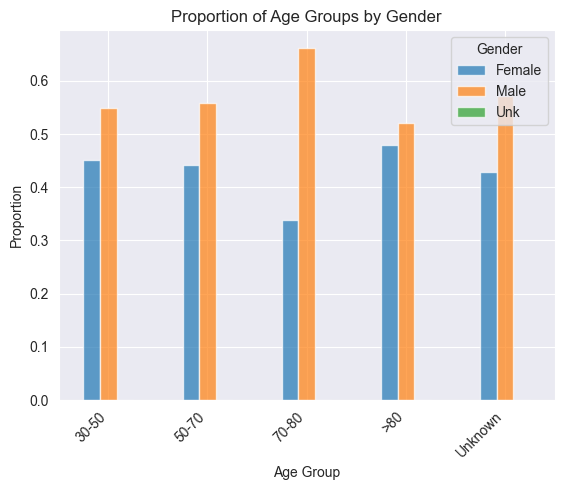

In [7]:
# Create a barplot for age groups per gender
age_gender_counts = ppmi_ad.obs.groupby(['Age_Group', 'Gender'])['Patient'].nunique().unstack(fill_value=0)
age_gender_counts = age_gender_counts.div(age_gender_counts.sum(axis=1), axis=0)

age_gender_counts.plot(kind='bar', stacked=False, color=color_map[:len(age_gender_counts.columns)], alpha=0.7)
plt.title('Proportion of Age Groups by Gender')
plt.ylabel('Proportion')
plt.xlabel('Age Group')
plt.xticks(rotation=45, horizontalalignment='right')
plt.legend(title='Gender')
plt.show()

/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_39883/3572932407.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Age_Group', 'Gender'])['Patient']


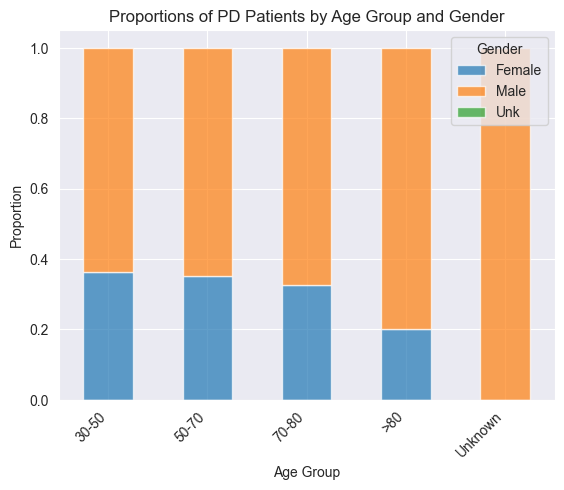

In [8]:
# Calculate the proportions of PD patients per age group and per gender
pd_age_gender_counts = (
    ppmi_ad.obs[ppmi_ad.obs['Diagnosis'] == 'PD']
    .groupby(['Age_Group', 'Gender'])['Patient']
    .nunique()
    .unstack(fill_value=0)
)
pd_age_gender_proportions = pd_age_gender_counts.div(pd_age_gender_counts.sum(axis=1), axis=0)

pd_age_gender_proportions.plot(
    kind='bar',
    stacked=True,
    color=color_map[:len(pd_age_gender_proportions.columns)],
    alpha=0.7
)
plt.title('Proportions of PD Patients by Age Group and Gender')
plt.ylabel('Proportion')
plt.xlabel('Age Group')
plt.xticks(rotation=45, horizontalalignment='right')
plt.legend(title='Gender')
plt.show()

In [9]:
# Identify patients belonging to more than one cohort
patients_multiple_cohorts = ppmi_ad.obs.groupby('Patient')['Diagnosis'].nunique()
patients_multiple_cohorts = patients_multiple_cohorts[patients_multiple_cohorts > 1]

print(f"Number of patients in more than one cohort: {len(patients_multiple_cohorts)}")
print(patients_multiple_cohorts)

Number of patients in more than one cohort: 0
Series([], Name: Diagnosis, dtype: int64)


/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_39883/3131751337.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diagnosis_gender_counts = ppmi_ad.obs.groupby(['Gender', 'Diagnosis'])['Patient'].nunique().unstack(fill_value=0)


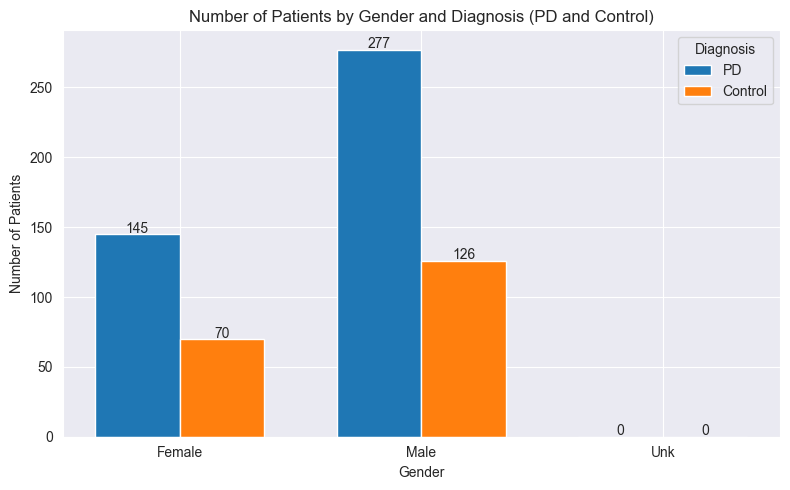

In [10]:
diagnosis_gender_counts = ppmi_ad.obs.groupby(['Gender', 'Diagnosis'])['Patient'].nunique().unstack(fill_value=0)

import matplotlib.pyplot as plt

# Filter only for "PD" and "Control" diagnoses
diagnosis_gender_filtered = diagnosis_gender_counts[['PD', 'Control']]

# Plot the bar chart
fig, ax = plt.subplots(figsize=(8, 5))

# Bar plot
bar_width = 0.35
genders = diagnosis_gender_filtered.index
x = range(len(genders))

for i, diag in enumerate(diagnosis_gender_filtered.columns):
    ax.bar(
        [pos + i * bar_width for pos in x],
        diagnosis_gender_filtered[diag],
        width=bar_width,
        label=diag
    )

# Annotate the bars with absolute numbers
for i, (index, row) in enumerate(diagnosis_gender_filtered.iterrows()):
    for j, value in enumerate(row):
        ax.text(
            i + j * bar_width, value + 1,
            str(value),
            ha='center',
            fontsize=10
        )

# Add plot labels and title
ax.set_title('Number of Patients by Gender and Diagnosis (PD and Control)')
ax.set_xlabel('Gender')
ax.set_ylabel('Number of Patients')
ax.set_xticks([pos + bar_width / 2 for pos in x])
ax.set_xticklabels(genders)
ax.legend(title='Diagnosis')
plt.tight_layout()
plt.show()

/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_39883/2385457043.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Age_Group', 'Diagnosis'])['Patient']


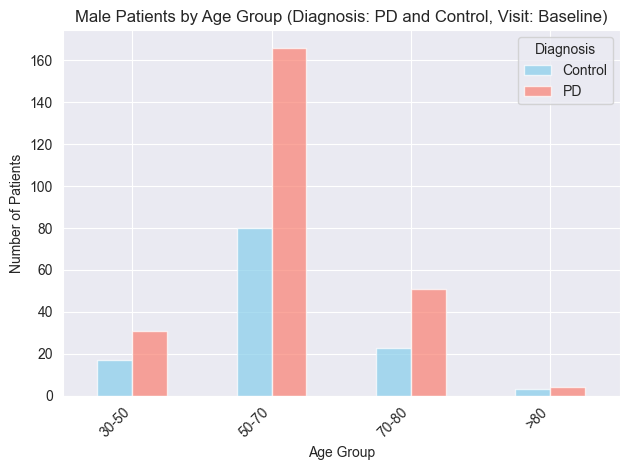

In [11]:
mask = ((ppmi_ad.obs['Gender'] == 'Male') &
        (ppmi_ad.obs['Diagnosis'].isin(['PD', 'Control'])) &
        (ppmi_ad.obs['Age_Group'] != 'Unknown') &
        (ppmi_ad.obs['Visit'] == 'BL'))

ppmi_ad_masked = ppmi_ad[mask]

baseline_age_counts = (
    ppmi_ad_masked.obs
    .groupby(['Age_Group', 'Diagnosis'])['Patient']
    .nunique()
    .unstack(fill_value=0)
)

baseline_age_counts.plot(kind='bar', stacked=False, color=['skyblue', 'salmon'], alpha=0.7)
plt.title('Male Patients by Age Group (Diagnosis: PD and Control, Visit: Baseline)')
plt.ylabel('Number of Patients')
plt.xlabel('Age Group')
plt.xticks(rotation=45, horizontalalignment='right')
plt.legend(title='Diagnosis')
plt.tight_layout()
plt.show()

/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_39883/1375022942.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Age_Group', 'Diagnosis'])['Patient']


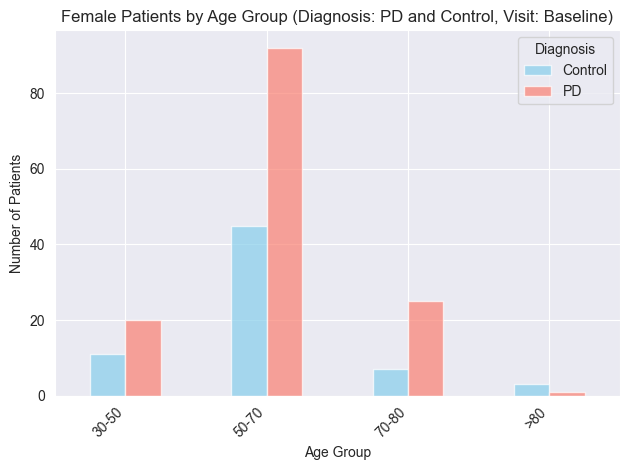

In [12]:
mask = ((ppmi_ad.obs['Gender'] == 'Female') &
        (ppmi_ad.obs['Diagnosis'].isin(['PD', 'Control'])) &
        (ppmi_ad.obs['Visit'] == 'BL'))

ppmi_ad_masked = ppmi_ad[mask]

baseline_age_counts = (
    ppmi_ad_masked.obs
    .groupby(['Age_Group', 'Diagnosis'])['Patient']
    .nunique()
    .unstack(fill_value=0)
)

baseline_age_counts.plot(kind='bar', stacked=False, color=['skyblue', 'salmon'], alpha=0.7)
plt.title('Female Patients by Age Group (Diagnosis: PD and Control, Visit: Baseline)')
plt.ylabel('Number of Patients')
plt.xlabel('Age Group')
plt.xticks(rotation=45, horizontalalignment='right')
plt.legend(title='Diagnosis')
plt.tight_layout()
plt.show()

/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_39883/2300360609.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Visit', 'Diagnosis'])['Patient']


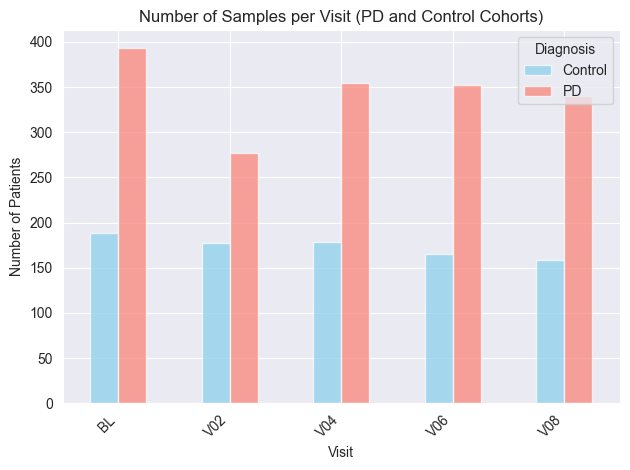

In [15]:
samples_per_visit = (
    ppmi_ad.obs[ppmi_ad.obs['Diagnosis'].isin(['PD', 'Control'])]
    .groupby(['Visit', 'Diagnosis'])['Patient']
    .nunique()
    .unstack(fill_value=0)
)

# Filter out the 'Unk' Visit
samples_per_visit = samples_per_visit[samples_per_visit.index != 'Unk']

samples_per_visit[['Control', 'PD']].plot(kind='bar', stacked=False, color=['skyblue', 'salmon'], alpha=0.7)
plt.title('Number of Samples per Visit (PD and Control Cohorts)')
plt.ylabel('Number of Patients')
plt.xlabel('Visit')
plt.xticks(rotation=45, horizontalalignment='right')
plt.legend(title='Diagnosis')
plt.tight_layout()
plt.show()

In [71]:
pd_ctrl = ppmi_ad.obs[ppmi_ad.obs['Diagnosis'].isin(['PD', 'Control'])]
# pd_ctrl[~pd_ctrl['Diagnosis'].isin(['PD', 'Control'])]
pd_ctrl.groupby(['Visit', 'Diagnosis', 'Gender'])['Patient'].nunique().unstack(['Diagnosis', 'Gender'], fill_value=0)

/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_9912/2407092317.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd_ctrl.groupby(['Visit', 'Diagnosis', 'Gender'])['Patient'].nunique().unstack(['Diagnosis', 'Gender'], fill_value=0)


Diagnosis Control          Genetic Cohort          Genetic Registry           \
Gender     Female Male Unk         Female Male Unk           Female Male Unk   
Visit                                                                          
BL             66  123   0              0    0   0                0    0   0   
Unk             0    0   0              0    0   0                0    0   0   
V02            63  114   0              0    0   0                0    0   0   
V04            65  114   0              0    0   0                0    0   0   
V06            64  101   0              0    0   0                0    0   0   
V08            61   98   0              0    0   0                0    0   0   

Diagnosis HCPOOL  ...  PD PDPOOL          Prodromal           SWEDD           
Gender    Female  ... Unk Female Male Unk    Female Male Unk Female Male Unk  
Visit             ...                                                         
BL             0  ...   0      0    0   0         0    0   0      0    0   0  
Unk            0  ...   0      0    0   0         0    0   0      0    0   0  
V02            0  ...   0      0    0   0         0    0   0      0    0   0  
V04            0  ...   0      0    0   0         0    0   0      0    0   0  
V06            0  ...   0      0    0   0         0    0   0      0    0   0  
V08            0  ...   0      0    0   0         0    0   0      0    0   0  

[6 rows x 24 columns]

/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_9912/1462600156.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samples_per_visit_gender.groupby(['Visit', 'Diagnosis', 'Gender'])['Patient']


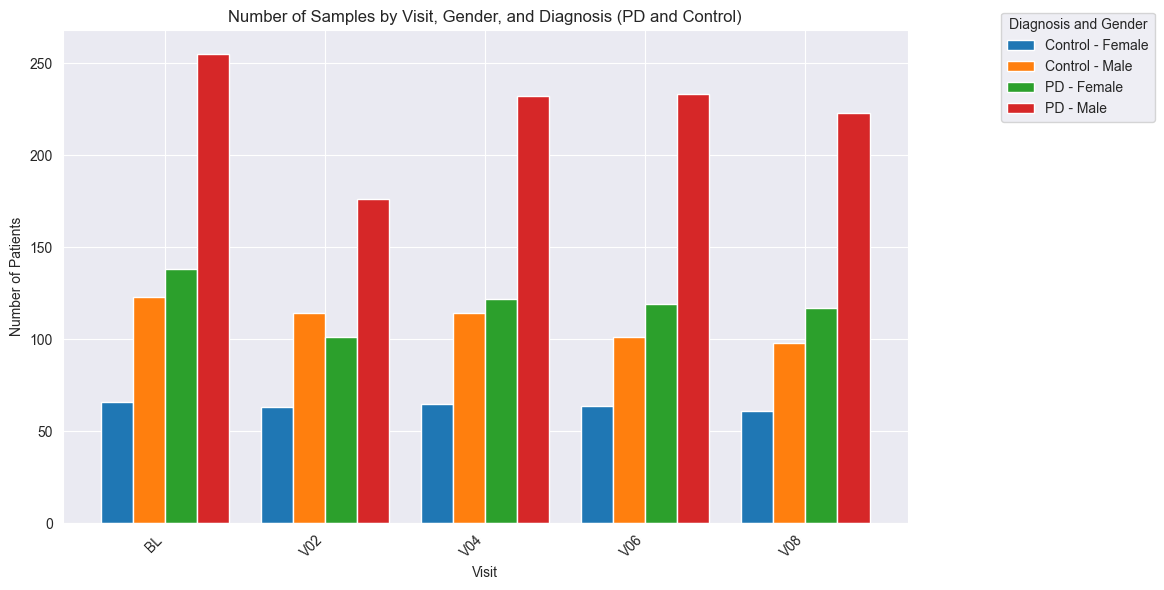

In [78]:
# Group samples by Visit, Diagnosis, and Gender
samples_per_visit_gender = (
    ppmi_ad.obs[ppmi_ad.obs['Diagnosis'].isin(['PD', 'Control'])]
)

samples_per_visit_gender = (
    samples_per_visit_gender.groupby(['Visit', 'Diagnosis', 'Gender'])['Patient']
    .nunique()
    .unstack(['Diagnosis', 'Gender'], fill_value=0)
)

# Remove columns that have all zeros
samples_per_visit_gender = samples_per_visit_gender.loc[:, (samples_per_visit_gender != 0).any(axis=0)]

# Filter out the 'Unk' Visit
samples_per_visit_gender = samples_per_visit_gender[samples_per_visit_gender.index != 'Unk']

# Generate the barplot with distinct bars for PD and Control
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.2  # Width of each bar
x = range(len(samples_per_visit_gender.index))  # X positions for the bars

# Plot each combination of Diagnosis and Gender using distinct bars
for i, (diagnosis, gender) in enumerate(samples_per_visit_gender.columns):
    ax.bar(
        [pos + i * bar_width for pos in x],  # Adjust position for each bar
        samples_per_visit_gender[(diagnosis, gender)],
        width=bar_width,
        label=f"{diagnosis} - {gender}"
    )

# Add plot labels and title
ax.set_title('Number of Samples by Visit, Gender, and Diagnosis (PD and Control)')
ax.set_ylabel('Number of Patients')
ax.set_xlabel('Visit')
ax.set_xticks([pos + bar_width * (len(samples_per_visit_gender.columns) / 2 - 0.5) for pos in x])  # Center xticks
ax.set_xticklabels(samples_per_visit_gender.index, rotation=45, horizontalalignment='right')
ax.legend(title='Diagnosis and Gender', loc='upper right', bbox_to_anchor=(1.3, 1.05))

plt.tight_layout()
plt.show()

/var/folders/qb/t7qv2b9n33n2xzbjvg_dk_4c0000gn/T/ipykernel_9912/3752177020.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Visit', 'Age_Group'])['Patient']


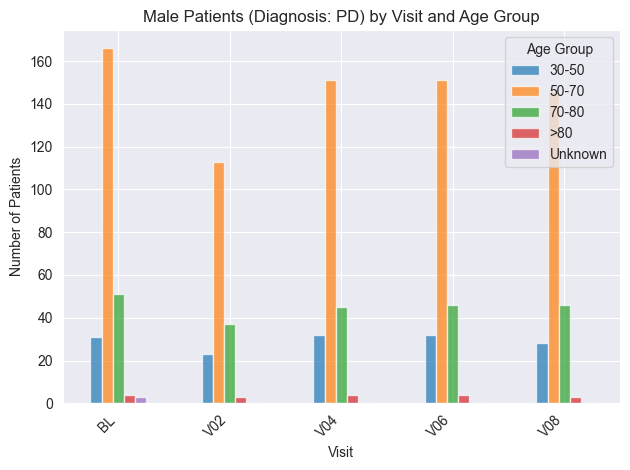

In [100]:
# Create a barplot for Diagnosis PD for each visit and age group for males

# Filtering AnnData for 'Male' Gender and 'PD' Diagnosis
mask = ((ppmi_ad.obs['Gender'] == 'Male') &
        (ppmi_ad.obs['Diagnosis'] == 'PD'))

ppmi_ad_masked = ppmi_ad[mask]

# Group by Visit and Age_Group
male_pd_age_group_counts = (
    ppmi_ad_masked.obs
    .groupby(['Visit', 'Age_Group'])['Patient']
    .nunique()
    .unstack(fill_value=0)
)

# Plotting the barplot
male_pd_age_group_counts.plot(kind='bar', stacked=False, color=color_map[:len(male_pd_age_group_counts.columns)], alpha=0.7)
plt.title('Male Patients (Diagnosis: PD) by Visit and Age Group')
plt.ylabel('Number of Patients')
plt.xlabel('Visit')
plt.xticks(rotation=45, horizontalalignment='right')
plt.legend(title='Age Group')
plt.tight_layout()
plt.show()